## Exploratory Data Analysis with Kaggle Data to see how it is
* Data is for SVG Generation from text prompts

Competition:
* build systems generate valid **SVG** code from NLP prompts
* Input : One prompt per sample
* Output : SVG string per Data id,svg format
* Submit mode Kaggle Code Sumission only ( no manual

## Goal today

### Undersand the prompts/texts side
* How long prompts?
* Icon style design ("a red circle") or scene description ("a sunset over mountains")
* Is consistent vocabulary/domain
* How many unique prompts vs total samples?

## Some info about the data ( Directly From Kaggle Data Description)

### Dataset Files

| File | Rows | Has SVG? | Purpose |
|---|---|---|---|
| `train.csv` | 50,000 | ✅ Yes | Training data — prompts + ground-truth SVGs |
| `test.csv` | 1,000 | ❌ No | Your model must generate SVGs for these |
| `sample_submission.csv` | 1,000 | ✅ (placeholder) | Shows required submission format |

---

### Column Schemas

| File | Column | Type | Description |
|---|---|---|---|
| `train.csv` | `id` | string | Unique UUID per row |
| `train.csv` | `prompt` | string | ~20 word natural language description |
| `train.csv` | `svg` | string | Ground-truth SVG code |
| `test.csv` | `id` | string | Unique UUID per row |
| `test.csv` | `prompt` | string | ~20 word natural language description |
| `sample_submission.csv` | `id` | string | Must match `test.csv` exactly, same order |
| `sample_submission.csv` | `svg` | string | Your generated SVG code |

---


### Key Obervations Pre-EDA

| Observation | Detail | Why It Matters |
|---|---|---|
| Unique prompts in train | ~45,900 out of 50,000 | Some prompts repeat — model must generalize, not memorize |
| Unique prompts in test | ~977 out of 1,000 | ~23 duplicate prompts in test set |
| Most common prompt pattern | "Generate svg code for an image that looks like: ... Don't use markdown just give svg code" | Prompts may be LLM-generated instructions, not clean descriptions |
| Placeholder submission SVG | A single black rectangle for all 1,000 rows | Baseline bar is very low — even simple valid outputs beat this |
| Unique SVGs in train | ~50,000 (nearly all unique) | Very little exact duplication in outputs |
| Total file size | 135.8 MB | Manageable in Colab, fits in memory easily |

### SVG Constraints


| Constraint | Limit |
|---|---|
| Max characters | 16,000 |
| Max `<path>` elements | 256 |
| Canvas size | 256 × 256 px |
| Invalid output penalty | Score = 0 for that row |





## Section 1: Setups, Imports

* Setting up kaggle ctl
* donwloading the data ( unzip)
* checking files exist
* load in Pandas

In [ ]:
from google.colab import files # upload kaggle.json
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"skn8733","key":"d61b778ae024ac6649a2686ff99aa3dd"}'}

In [ ]:
# creating kaggle directory in root and giving permission to write+read
import os  #  move kaggle.json to the right place
os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.kaggle/kaggle.json')
# permissions
os.chmod('/root/.kaggle/kaggle.json', 0o600) # setting the json file to 600 permission (own+rw)



In [ ]:
!pip install kaggle # install kaggle

In [ ]:
# Step 4 — download the competition data
# paste your exact competition name from the Kaggle URL
!kaggle competitions download -c dl-spring-2026-svg-generation

100% 32.4M/32.4M [00:02<00:00, 12.0MB/s]



In [ ]:
# Step 5: Unzipping the
import zipfile
with zipfile.ZipFile('dl-spring-2026-svg-generation.zip', 'r') as zip_ref:
    zip_ref.extractall('data/')


In [ ]:
# Step 6 — confirm files are there
print(os.listdir('data/'))

['test.csv', 'train.csv', 'sample_submission.csv']


## Section 2: Data Download & Basic Data Inspection

In [ ]:
## Getting the right libraries downloaded for EDA
import pandas as pd          # loading and manipulating the CSV data
import matplotlib.pyplot as plt  # plotting distributions and charts
from IPython.display import SVG, display  # rendering SVGs visually in Colab



In [ ]:
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')
sample_df = pd.read_csv('data/sample_submission.csv')

In [ ]:
print(train_df.shape)
print(test_df.shape)
print(sample_df.shape)

(50000, 3)
(1000, 2)
(1000, 2)


Now we got the downloaded data
* Look through data
* check missing values
* Look at raw svg strings, prompt
* look at few prompts + SVG pairs

In [ ]:
print("=== TRAIN ===")
print(train_df.head())
print("\n=== TEST ===")
print(test_df.head())
print("\n=== SAMPLE SUBMISSION ===")
print(sample_df.head())

=== TRAIN ===
                                           id  \
0            fd61e324e0cec5c11f337d0bfe2858c8   
1            999b3d4d5a860725bf9528910b5612f3   
2            1aaa84517819c25f783ae1c0cb337fc5   
3            919a7da8bd44dc7781dbe87383a268cc   
4  thesantatitan_deepseek-svg-dataset_0000581   

                                              prompt  \
0  The image features two orange squares with a m...   
1  A simple smiley face with a wide open mouth an...   
2  The image features a black-outlined icon of a ...   
3  The image displays a black icon with a photo-l...   
4  Generate svg code for an image that looks like...   

                                                 svg  
0  <svg xmlns="http://www.w3.org/2000/svg" viewBo...  
1  <svg xmlns="http://www.w3.org/2000/svg" viewBo...  
2  <svg xmlns="http://www.w3.org/2000/svg" viewBo...  
3  <svg xmlns="http://www.w3.org/2000/svg" viewBo...  
4  <svg width="24" height="24" viewBox="0 0 24 24...  

=== TEST ===
          

In [ ]:
print("=== TRAIN null counts ===")
print(train_df.isnull().sum())
print("\n=== TEST null counts ===")
print(test_df.isnull().sum())

=== TRAIN null counts ===
id        0
prompt    0
svg       0
dtype: int64

=== TEST null counts ===
id        0
prompt    0
dtype: int64


In [ ]:
# check duplicate prompts in train
print("=== DUPLICATES ===")
print(f"Total rows: {len(train_df)}")
print(f"Unique prompts: {train_df['prompt'].nunique()}")
print(f"Duplicate prompts: {len(train_df) - train_df['prompt'].nunique()}")

=== DUPLICATES ===
Total rows: 50000
Unique prompts: 45931
Duplicate prompts: 4069


In [ ]:
# check duplicate SVGs
print(f"Unique SVGs: {train_df['svg'].nunique()}")
print(f"Duplicate SVGs: {len(train_df) - train_df['svg'].nunique()}")

Unique SVGs: 49993
Duplicate SVGs: 7


In [ ]:
# check duplicate prompt+svg pairs together
print(f"Unique prompt+svg pairs: {train_df.drop_duplicates(subset=['prompt','svg']).shape[0]}")

Unique prompt+svg pairs: 50000


This means that **every row is unique and no duplicates. The duplicate prompts means same prompt appears multiple times but paired with different SVGs each time**. For example:
* "a red circle"  →  SVG version 1
* "a red circle"  →  SVG version 2
* "a red circle"  →  SVG version 3

The 7 duplicate SVGs means same SVG appears with different prompts.

## Section 3: SVG Analysis &  Visual Rendering

In [ ]:
print(train_df['svg'][0])

<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 200.0 200.0" height="200.0px" width="200.0px"><path fill="#FF6A00" fill-opacity="1.0"  filling="0" d="M93.30000305175781 21.20000457763672 L93.30000305175781 80.4000015258789 L21.20000457763672 80.4000015258789 L21.20000457763672 179.60000610351562 L120.4000015258789 179.60000610351562 L120.4000015258789 107.0999984741211 L179.10000610351562 107.0999984741211 L179.10000610351562 21.20000457763672 L93.30000305175781 21.20000457763672 Z M113.80000305175781 172.89999389648438 L27.900001525878906 172.89999389648438 L27.900001525878906 87.0999984741211 L113.69999694824219 87.0999984741211 L113.69999694824219 172.89999389648438 L113.80000305175781 172.89999389648438 Z M172.5 100.39999389648438 L120.4000015258789 100.39999389648438 L120.4000015258789 80.4000015258789 L100.0 80.4000015258789 L100.0 27.900001525878906 L172.5 27.900001525878906 L172.5 100.39999389648438 Z"></path>
<path fill="#FF6A00" fill-opacity="1.0"  filling="0" d="M14

In [ ]:
## Seeing how the svg code/image looks like as well
!pip install cairosvg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 4.7 MB/s eta 0:00:00


In [ ]:
import cairosvg
from PIL import Image
import io

In [ ]:
# Rendering image
def render_svg(svg_string):
    png_bytes = cairosvg.svg2png(bytestring=svg_string.encode())
    img = Image.open(io.BytesIO(png_bytes))
    return img

The image features two orange squares with a microphone icon and an arrow connecting them, set against a white background.



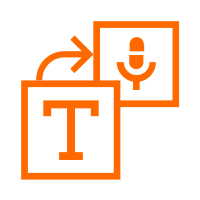

In [ ]:
# test the render
# render the first SVG
img = render_svg(train_df['svg'][0])
print(train_df['prompt'][0] + "\n")  # print the prompt above it so you know what it's supposed to look like
display(img)

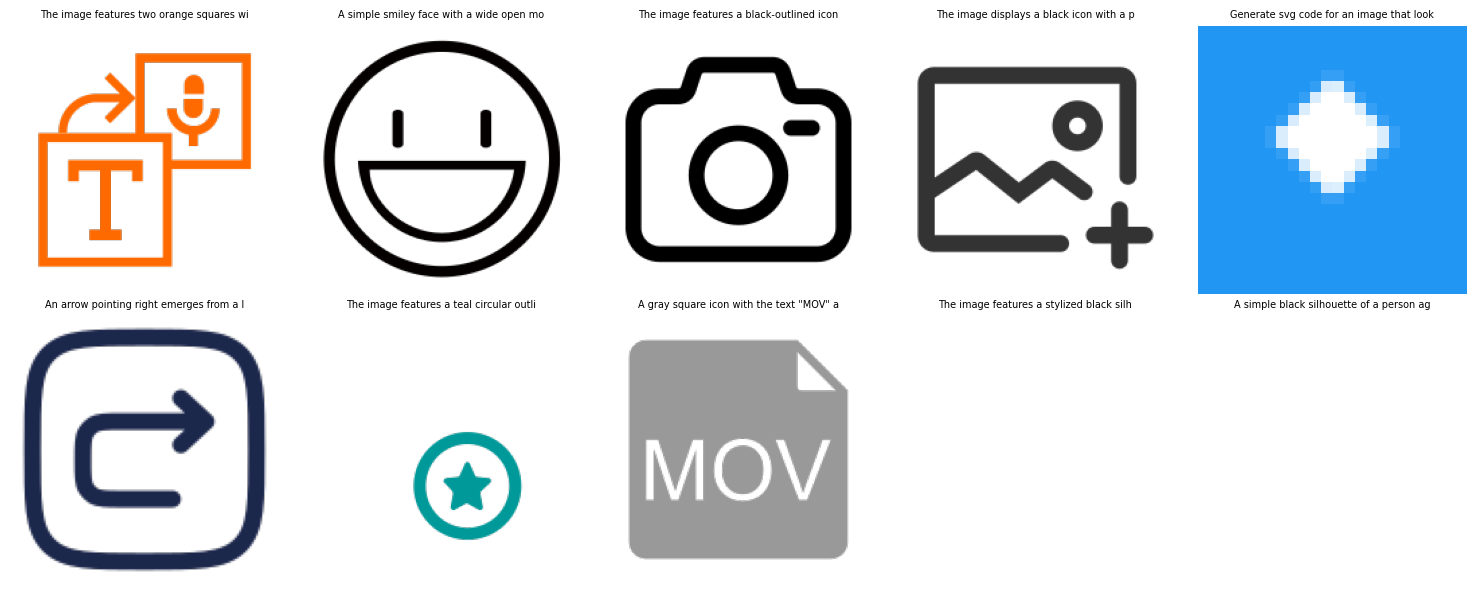

In [ ]:
# Print to check several

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flatten()):
    img = render_svg(train_df['svg'][i])
    ax.imshow(img)
    ax.set_title(train_df['prompt'][i][:40], fontsize=7, wrap=True)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# It looks like two of the prompts didn't show the image
# find the rows with those prompts
mask = train_df['prompt'].str.contains('The image features a stylized black silh|A simple black silhouette of a person ag', case=False)
print(train_df[mask][['prompt', 'svg']].head())

                                                  prompt  \
8      The image features a stylized black silhouette...   
9      A simple black silhouette of a person against ...   
10049  The image features a stylized black silhouette...   
17008  The image features a simple black silhouette o...   
26287  The image shows a simple black silhouette of a...   

                                                     svg  
8      <svg xmlns="http://www.w3.org/2000/svg" viewBo...  
9      <svg xmlns="http://www.w3.org/2000/svg" viewBo...  
10049  <svg xmlns="http://www.w3.org/2000/svg" viewBo...  
17008  <svg xmlns="http://www.w3.org/2000/svg" viewBo...  
26287  <svg xmlns="http://www.w3.org/2000/svg" viewBo...  


In [ ]:
# get the index of those rows
indices = train_df[mask].index.tolist()
print("Indices:", indices)

for idx in indices:
    print(f"\nPROMPT: {train_df['prompt'][idx]}")
    print(f"\nSVG CODE:\n{train_df['svg'][idx]}")
    print("---")

Indices: [8, 9, 10049, 17008, 26287, 27965, 28348, 28591, 37522, 46597, 49910]

PROMPT: The image features a stylized black silhouette of a crescent moon with wavy lines extending from the right side, set against a white background.

SVG CODE:
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 200.0 200.0" height="200.0px" width="200.0px"><path fill="" fill-opacity="1.0"  filling="0" d="M59.67422103881836 14.528121948242188 C47.09902572631836 29.407623291015625 37.765037536621094 46.786521911621094 32.375587463378906 65.49336242675781 C32.375587463378906 65.57148742675781 32.336517333984375 65.61054992675781 32.336517333984375 65.68867492675781 C16.988479614257812 72.01522827148438 6.248634338378906 87.09004211425781 6.248634338378906 104.66425323486328 C6.248634338378906 127.9404296875 25.150588989257812 146.8425750732422 48.4267578125 146.8425750732422 C71.70292663574219 146.8425750732422 90.6048812866211 127.9404296875 90.6048812866211 104.66425323486328 C90.6048812866211 83.7

Index 8 — rendered OK


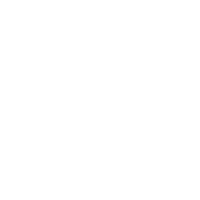

Index 9 — rendered OK


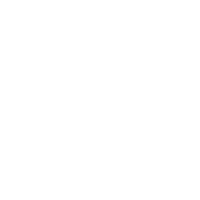

Index 10049 — rendered OK


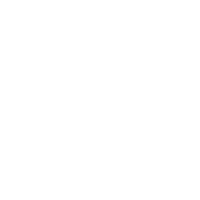

Index 17008 — rendered OK


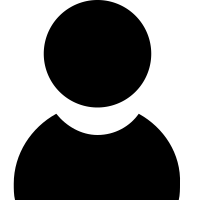

Index 26287 — rendered OK


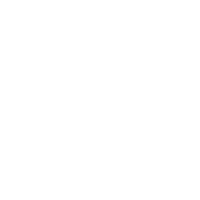

Index 27965 — rendered OK


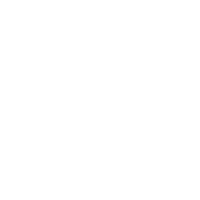

Index 28348 — rendered OK


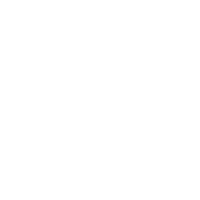

Index 28591 — rendered OK


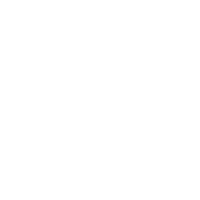

Index 37522 — rendered OK


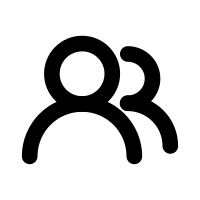

Index 46597 — rendered OK


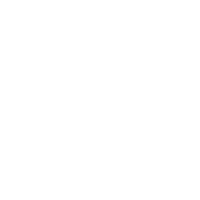

Index 49910 — rendered OK


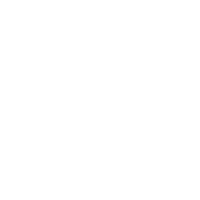

In [ ]:
# render those images one by one to see if they show up

for idx in indices:
    try:
        img = render_svg(train_df['svg'][idx])
        print(f"Index {idx} — rendered OK")
        display(img)
    except Exception as e:
        print(f"Index {idx} — FAILED: {e}")

## Observation about the SVGs

It looks like the SVG codes witht the cases of **Empty fill attribute** and **Wrong Canvas Size** exits.

### Empty fill attributes

This means that ```fill=""``` attribute in a SVG code output such at the following ```<path fill="" fill-opacity="1.0" ...>``` means no color specificed which rendered blank.

### Wrong canvas size
The size of the SVG ``` viewBox="0.0 0.0 200.0 200.0" height="200.0px" width="200.0px"``` means that not being 256x256 violates the traiing data itself.

So this tells that :
* Some of the training SVGs maybe malformed/broken
* Training data **is not perfectly clean**
* Can't blindly trust 50k samples as good learn from



In [ ]:
# Lets check how many do we have that meet these two conditions

empty_fill = train_df['svg'].str.contains('fill=""').sum()
print(f"SVGs with empty fill: {empty_fill}")


SVGs with empty fill: 8696


In [ ]:
# check how many are not 256x256
not_256 = train_df['svg'].str.contains('width="256"').sum()
print(f"SVGs with correct 256 width: {not_256}")
print(f"SVGs without correct 256 width: {len(train_df) - not_256}")

SVGs with correct 256 width: 11
SVGs without correct 256 width: 49989


Now we have some clarity on the construct of the training data with SVG, we can move onto counting the length of **SVG Length**, **Path Count**, **disallowed elements** of the training data.

Note: It is important to keep in mind to keep as much of the variety of the training data even with analytics showing cases. This can help benefit in **model learn visual patterns from training data shapes, colors, compositions**. We can resize/normalize these things in **output without losing what model is learned visually**

In [ ]:
# 1. SVG length - are any over 16000 chars
print("=== LENGTH CHECK ===")
train_df['svg_len'] = train_df['svg'].str.len()
print(train_df['svg_len'].describe())
over_limit = (train_df['svg_len'] > 16000).sum()
print(f"SVGs over 16000 chars: {over_limit}")

# 2. Path count
print("\n=== PATH COUNT ===")
train_df['path_count'] = train_df['svg'].str.count('<path')
print(train_df['path_count'].describe())
over_256 = (train_df['path_count'] > 256).sum()
print(f"SVGs with over 256 paths: {over_256}")

# 3. Disallowed elements
print("\n=== DISALLOWED ELEMENTS ===")
disallowed = ['script', 'animate', 'foreignObject']
for tag in disallowed:
    count = train_df['svg'].str.contains(tag).sum()
    print(f"{tag}: {count}")


=== LENGTH CHECK ===
count    50000.000000
mean      2524.277000
std       1773.833419
min         91.000000
25%       1125.000000
50%       2110.000000
75%       3530.000000
max      15937.000000
Name: svg_len, dtype: float64
SVGs over 16000 chars: 0

=== PATH COUNT ===
count    50000.000000
mean         2.420120
std          3.427298
min          0.000000
25%          1.000000
50%          1.000000
75%          3.000000
max        303.000000
Name: path_count, dtype: float64
SVGs with over 256 paths: 1

=== DISALLOWED ELEMENTS ===
script: 0
animate: 0
foreignObject: 0


Lets look at the visuals for the SVG.
1. SVG length distribution
2. Path count distribution

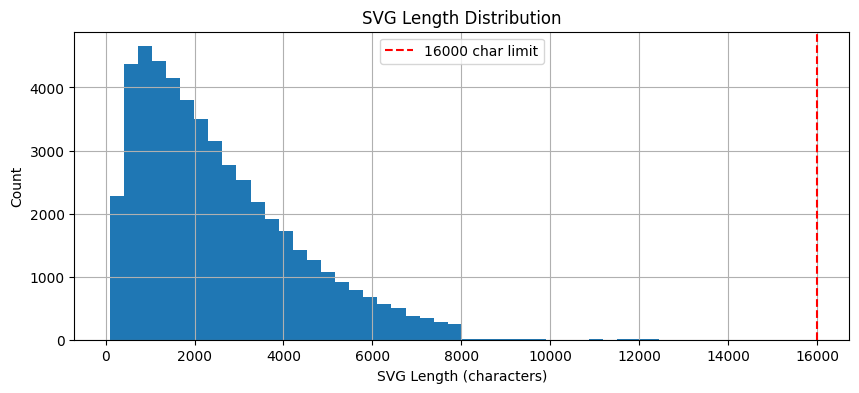

In [ ]:
plt.figure(figsize=(10, 4))
train_df['svg_len'].hist(bins=50)
plt.axvline(x=16000, color='red', linestyle='--', label='16000 char limit')
plt.xlabel('SVG Length (characters)')
plt.ylabel('Count')
plt.title('SVG Length Distribution')
plt.legend()
plt.show()

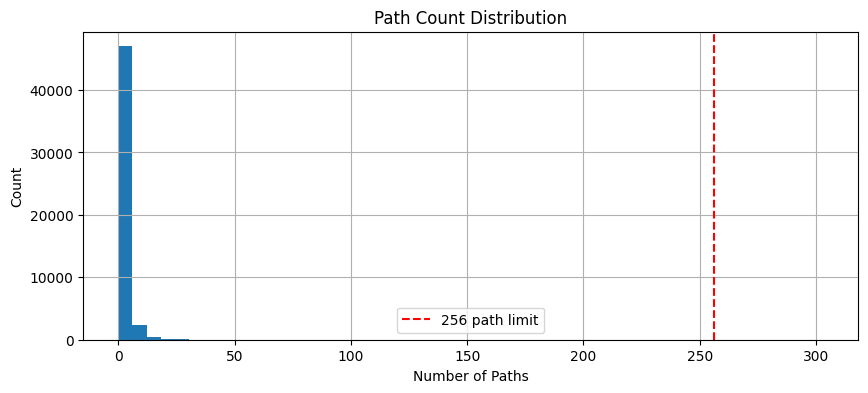

In [ ]:
plt.figure(figsize=(10, 4))
train_df['path_count'].hist(bins=50)
plt.axvline(x=256, color='red', linestyle='--', label='256 path limit')
plt.xlabel('Number of Paths')
plt.ylabel('Count')
plt.title('Path Count Distribution')
plt.legend()
plt.show()

## SVG Analysis Observations

**SVG Length Distribution:**
- Distribution is right-skewed (positive skew) with the majority of SVGs falling in the [0, 2000] character range
- A small tail extends toward ~12,000 characters
- No SVGs exceed the 16,000 character limit — this constraint is not a concern for the training data

**Path Count Distribution:**
- Majority of SVGs contain between [0, 50] paths
- No SVGs exceed the 256 path limit — well within the competition constraint
- Low path counts suggest the dataset consists of simple, flat graphics and icons rather than complex detailed illustrations

**Disallowed Elements:**
- No occurrences of disallowed tags (script, animate, foreignObject) found in training data

**Key Takeaway:**
The training SVGs are short, structurally simple, and well within all competition constraints.
This suggests the dataset is primarily composed of simple icons and flat vector graphics
rather than complex scenes. This is promising for a fine-tuned seq2seq approach as the
model does not need to generate long or geometrically complex outputs to match the
training distribution.

## Section 4: Prompt Analysis

In this section we analyze the text prompts from the training data to understand
the vocabulary, structure, and complexity of what our model needs to interpret.

- **Prompt Length Distribution** — measure how many words each prompt contains on
average to understand the complexity of text inputs our model needs to handle

- **Most Common Words** — identify the most frequent vocabulary across all prompts
to understand the domain and whether prompts are constrained to specific themes
like icons, objects, or scenes

- **Prompt Structure Patterns** — check if prompts follow a consistent template
or format, for example the "Generate svg code for an image that looks like..."
pattern observed earlier in the dataset

- **Prompt vs SVG Relationship** — examine whether similar prompts produce
structurally similar SVGs, which tells us how consistent and learnable the
prompt-to-SVG mapping is

count    50000.000000
mean        19.719340
std         10.334334
min          1.000000
25%         12.000000
50%         17.000000
75%         24.000000
max        127.000000
Name: prompt_len, dtype: float64


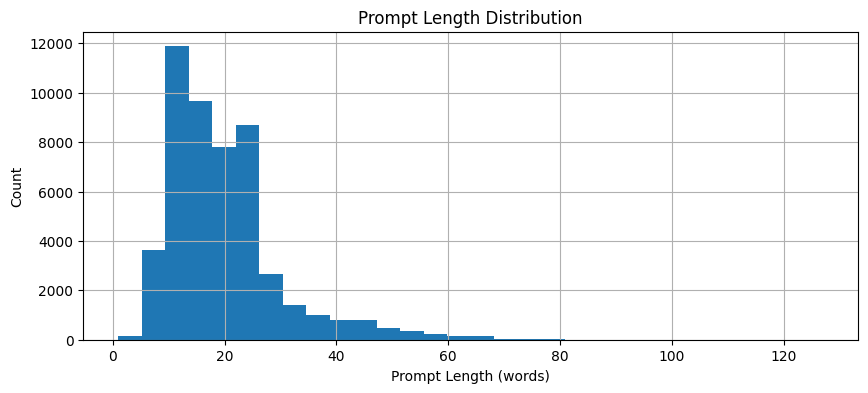

In [ ]:
# prompt length distribution
train_df['prompt_len'] = train_df['prompt'].str.split().str.len()
print(train_df['prompt_len'].describe())

plt.figure(figsize=(10, 4))
train_df['prompt_len'].hist(bins=30)
plt.xlabel('Prompt Length (words)')
plt.ylabel('Count')
plt.title('Prompt Length Distribution')
plt.show()

It looks like we found a outltier in the group for prompt length. While most vary from 17-24 in prompt length, this outlier would be good to look into. Also just out oc curiousity lets see what the shortest length prompt looks like as well

In [ ]:
# find the longest prompts
print(train_df.nlargest(5, 'prompt_len')[['prompt', 'prompt_len']])


                                                  prompt  prompt_len
49611  A smallcaps "x" Cap quiet,Spain? modern? weapo...         127
2889   The image shows a black rectangular frame cont...         104
26587  The image displays a black rectangular shape w...          98
10456  The image features a stylized logo composed of...          95
20085  The image features a black circular outline co...          94
                      prompt  prompt_len
3299                   Close           1
6117    圆圈内有两双大眼睛和一条直线嘴巴的图案。           1
9264             Moonshining           1
11307            picture.png           1
16231  指纹扫描技术,数码设备上安全身份的确认方式           1


In [ ]:
# and the shortest
print(train_df.nsmallest(5, 'prompt_len')[['prompt', 'prompt_len']])

                      prompt  prompt_len
3299                   Close           1
6117    圆圈内有两双大眼睛和一条直线嘴巴的图案。           1
9264             Moonshining           1
11307            picture.png           1
16231  指纹扫描技术,数码设备上安全身份的确认方式           1


Shortest prompts are concerning:

"Close", "Moonshining", "picture.png" — these are essentially meaningless as prompts
Chinese/non-English prompts like "圆圈内有两双大眼睛" — your model needs to handle or filter these
"picture.png" is literally just a filename, not a description at all

Longest prompts:

127 words is an outlier but looks like garbled/noisy text ("Cap quiet, Spain? modern? weapo...")
These are likely bad data points

In [ ]:
# how many non-english prompts exist
non_english = train_df['prompt'].str.contains('[^\x00-\x7F]').sum()
print(f"Prompts with non-ASCII characters: {non_english}")

# how many very short prompts (under 3 words)
very_short = (train_df['prompt_len'] < 3).sum()
print(f"Prompts under 3 words: {very_short}")

# how many very long prompts (over 50 words)
very_long = (train_df['prompt_len'] > 50).sum()
print(f"Prompts over 50 words: {very_long}")

Prompts with non-ASCII characters: 794
Prompts under 3 words: 20
Prompts over 50 words: 1104


In [ ]:
# Check some overlap since we have some non ASCII character/ non_english prompts
# check overlap between problem groups
non_ascii = train_df['prompt'].str.contains('[^\x00-\x7F]')
very_short = train_df['prompt_len'] < 3
very_long = train_df['prompt_len'] > 50

print(f"Non-ASCII: {non_ascii.sum()}")
print(f"Under 3 words: {very_short.sum()}")
print(f"Over 50 words: {very_long.sum()}")
print(f"Any problem: {(non_ascii | very_short).sum()}")
print(f"Total to remove: {(non_ascii | very_short).sum()}")

Non-ASCII: 794
Under 3 words: 20
Over 50 words: 1104
Any problem: 805
Total to remove: 805


In [ ]:
# create clean version of training data
non_ascii = train_df['prompt'].str.contains('[^\x00-\x7F]')
very_short = train_df['prompt_len'] < 3

train_clean = train_df[~(non_ascii | very_short)].reset_index(drop=True)

print(f"Original: {len(train_df)} rows")
print(f"Removed: {len(train_df) - len(train_clean)} rows")
print(f"Remaining: {len(train_clean)} rows")

Original: 50000 rows
Removed: 805 rows
Remaining: 49195 rows


## Prompt Analysis Findings

**Prompt Length Distribution:**
- Average prompt length is ~20 words (mean: 19.7, median: 17)
- Distribution is right-skewed with a long tail extending up to 127 words
- The majority of prompts fall comfortably within the [12, 24] word range

**Longest Prompts:**
- Prompts exceeding 50 words (1,104 total) tend to be overly verbose
  but mostly valid descriptions
- The longest prompt at 127 words appeared garbled and noisy
  ("Cap quiet, Spain? modern? weapo...") suggesting some data collection
  artifacts at the extremes

**Shortest Prompts:**
- 20 prompts contained fewer than 3 words
- These included single words like "Close", filenames like "picture.png",
  and non-descriptive entries — not useful for training

**Non-English Prompts:**
- 794 prompts contained non-ASCII characters including Chinese text
- These were identified as unusable since our text encoder (CLIP/T5)
  is primarily trained on English text and would produce poor embeddings
- Translation was not pursued as this represents only 1.6% of the dataset

**Data Cleaning Decision:**
- Removed 805 rows total (1.6% of dataset)
  - 794 non-ASCII/non-English prompts
  - 20 prompts under 3 words
  - 9 rows overlapped both categories
- Prompts over 50 words were kept as they are mostly valid descriptions
- Final clean training set: 49,195 rows

In [ ]:
# most common words in prompts
from collections import Counter
words = Counter()
for p in train_df['prompt']:
    words.update(p.lower().split())
print(words.most_common(30))

[('a', 129242), ('the', 49228), ('with', 34380), ('black', 32720), ('white', 30666), ('image', 23069), ('and', 20850), ('of', 20217), ('background.', 18600), ('icon', 17865), ('against', 15013), ('on', 10515), ('an', 9868), ('features', 9183), ('circular', 8219), ('two', 7646), ('blue', 7024), ('set', 6941), ('shape', 6663), ('simple', 6577), ('line', 6495), ('in', 6180), ('is', 5971), ('horizontal', 5616), ('shows', 5609), ('code', 5476), ('lines', 5457), ('svg', 5439), ('or', 5422), ('rectangular', 5307)]


Look at what's in the top 30 most common words — "black", "white", "icon", "circular", "simple", "background", "svg", "code". That's very telling. Explore it:

In [ ]:
# how many prompts contain the word "icon"
icon_count = train_df['prompt'].str.contains('icon', case=False).sum()
print(f"Prompts mentioning icon: {icon_count}")

# how many mention specific colors
colors = ['black', 'white', 'blue', 'red', 'green', 'yellow']
for color in colors:
    count = train_df['prompt'].str.contains(color, case=False).sum()
    print(f"{color}: {count}")

Prompts mentioning icon: 18603
black: 27913
white: 28169
blue: 6509
red: 8037
green: 1331
yellow: 1441


In [ ]:
# how many follow the "Generate svg code" template
template_count = train_df['prompt'].str.contains('Generate svg code', case=False).sum()
print(f"Prompts following Generate svg code template: {template_count}")
print(f"Percentage: {template_count/len(train_df)*100:.1f}%")

Prompts following Generate svg code template: 2719
Percentage: 5.4%


## Most Common Words and Prompt Structure

**Most Common Words:**
- Stopwords dominate (a, the, with, of) which is expected
- Most significant content words are:
  - Colors: black (32,720), white (30,666), blue (7,024), red (8,037)
  - Structure words: icon (17,865), circular (8,219), simple (6,577),
    shape (6,663), line (6,495)
  - Descriptive: background (18,600), features (9,183)
- Dataset is heavily monochromatic — black and white dominate color mentions
- Strong icon vocabulary confirms dataset is primarily flat icon graphics

**Prompt Structure Patterns:**
- Only 5.4% (2,719 prompts) follow the explicit
  "Generate svg code for an image that looks like..." template
- The remaining 94.6% use varied natural language descriptions
- This means prompts have no single fixed format —
  the text encoder must handle flexible natural language input

### Prompt vs SVG Relationship

In this section we examine whether the same prompt consistently produces
similar SVGs or wildly different ones across the training data.

- **Identify Repeated Prompts** — find prompts that appear more than once
  in the training data to use as comparison cases

- **Select an Example** — pick the most frequently repeated prompt to
  use as our test case

- **Render All Versions** — visually render every SVG associated with
  that same prompt side by side to see how consistent or varied the
  outputs are

- **Observe Consistency** — determine whether the same prompt produces
  structurally similar SVGs or completely different interpretations,
  which tells us how learnable and consistent the prompt-to-SVG
  mapping is in the training data

In [ ]:
# Step 1 — identify repeated prompts
duplicate_prompts = train_df[train_df.duplicated(subset=['prompt'], keep=False)]
duplicate_prompts = duplicate_prompts.sort_values('prompt')
print(f"Rows with repeated prompts: {len(duplicate_prompts)}")
print(f"Unique repeated prompts: {duplicate_prompts['prompt'].nunique()}")

Rows with repeated prompts: 5140
Unique repeated prompts: 1071


In [ ]:
# Step 2 — find the most repeated prompt
most_repeated = train_df['prompt'].value_counts()
print("Top 5 most repeated prompts:")
print(most_repeated.head())

Top 5 most repeated prompts:
prompt
Generate svg code for an image that looks like: a black background with a white and red flower. Don't use markdown just give svg code    1788
Generate svg code for an image that looks like: the logo for the company. Don't use markdown just give svg code                            34
The image is completely filled with a solid black color.                                                                                   33
Generate svg code for an image that looks like: the logo for the new logo for the new company. Don't use markdown just give svg code       24
A simple black cross symbol on a white background.                                                                                         21
Name: count, dtype: int64


The top prompt appearing 1,788 times is a serious data quality issue:

* "Generate svg code for an image that looks like: a black background with a white and red flower"
* This is clearly a data collection artifact — someone or some process repeatedly submitted the same prompt
* 1,788 SVGs of the same flower prompt will heavily bias your model toward generating flower-like outputs

In [ ]:
# check how many rows that single prompt takes up
top_prompt = most_repeated.index[0]
top_count = most_repeated.iloc[0]
print(f"Top prompt count: {top_count}")
print(f"Percentage of dataset: {top_count/len(train_df)*100:.1f}%")

# keep only one instance of it in train_clean
# rather than removing all, keep one so the model still knows the pattern
train_clean = train_clean.drop_duplicates(subset=['prompt']).reset_index(drop=True)
print(f"After removing prompt duplicates: {len(train_clean)} rows")

Top prompt count: 1788
Percentage of dataset: 3.6%
After removing prompt duplicates: 45129 rows


In [ ]:
# Step 3 — pick the most repeated and get all its versions
example_prompt = most_repeated.index[0]
print(f"Selected prompt: {example_prompt}")
print(f"Appears {most_repeated.iloc[0]} times")

versions = train_df[train_df['prompt'] == example_prompt].reset_index(drop=True)
print(f"Number of SVG versions: {len(versions)}")

Selected prompt: Generate svg code for an image that looks like: a black background with a white and red flower. Don't use markdown just give svg code
Appears 1788 times
Number of SVG versions: 1788


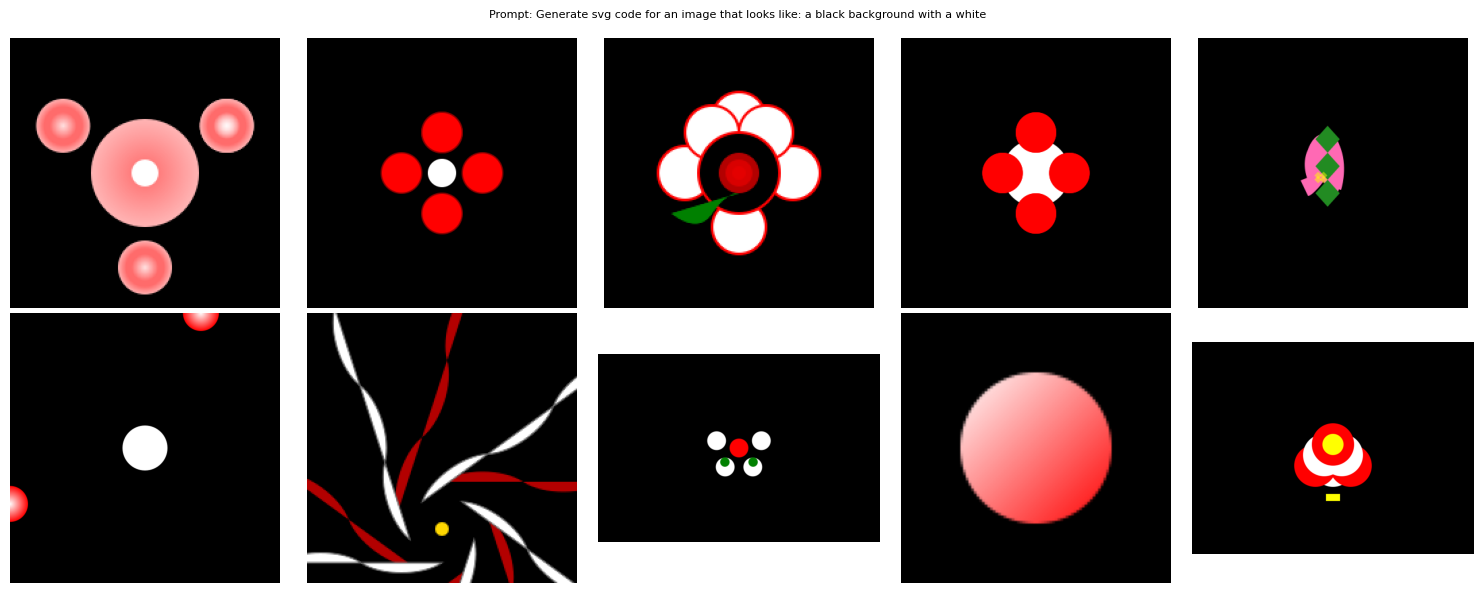

In [ ]:
# Step 4 — render first 10 versions only
sample_versions = versions.head(10)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for ax, (_, row) in zip(axes.flatten(), sample_versions.iterrows()):
    try:
        img = render_svg(row['svg'])
        ax.imshow(img)
    except Exception as e:
        ax.text(0.5, 0.5, 'render failed', ha='center')
    ax.axis('off')

plt.suptitle(f"Prompt: {example_prompt[:80]}", fontsize=8)
plt.tight_layout()
plt.show()

## EDA Summary

**Dataset:**
- 50,000 training samples, 1,000 test samples
- Prompts average ~20 words, primarily English natural language descriptions
- Dataset is heavily icon-focused and monochromatic (black/white dominant)

**SVG Characteristics:**
- Short and simple — majority under 2,000 characters
- Low path counts — majority under 50 paths
- Well within competition constraints on length and path count
- No disallowed elements found in training data
- Canvas sizes vary widely — only 11 samples use 256x256

**Data Quality Issues Found:**
- 8,696 SVGs with empty fill attributes
- 794 non-English prompts
- 20 prompts under 3 words
- 1,788 duplicate flower prompts (3.6% of dataset)

**After Cleaning:**
- Final training set: 45,130 rows

**Key Takeaways for Training:**
- Seq2seq fine-tuning is a realistic approach given SVG simplicity
- T5-base or CLIP text encoder is sufficient for ~20 word prompts
- Canvas normalization must be handled at inference time
- Validity post-processing is essential before submission
```

---

## What the Training Notebook Should Do

Based directly on your EDA findings, here is the natural flow:
```
1. Setup and Imports
   - Load libraries
   - Set random seeds for reproducibility

2. Data Loading and Cleaning
   - Download raw train.csv from Kaggle
   - Reapply same cleaning steps from EDA
     - Remove non-ASCII prompts
     - Remove under 3 word prompts
     - Remove duplicate prompts
   - Confirm 45,130 clean rows

3. Data Preparation
   - Tokenize prompts using chosen text encoder
   - Tokenize SVG strings as target sequences
   - Create train/validation split (e.g. 90/10)

4. Model Setup
   - Load pretrained model (T5-base or similar)
   - Configure for seq2seq SVG generation

5. Training Loop
   - Forward pass
   - Compute loss
   - Backward pass
   - Save checkpoints periodically
   - Track validation loss

6. Save Best Weights
   - Save best checkpoint to Google Drive